# ⚡ Household Electric Power Consumption

[Kaggle Dataset Link](https://www.kaggle.com/datasets/uciml/electric-power-consumption-data-set )

## 📘 Dataset Overview - Business Problem

The **Household Electric Power Consumption** dataset contains minute-level measurements of electricity usage collected over almost four years.

This project aims to **analyze and predict household energy consumption patterns** using a **Recurrent Neural Network (RNN)** model.  

It includes multiple electrical quantities and sub-metering values representing different areas of the house.

---

### 🎯 Project Objective

- **Target Variable:** `Global_active_power`  

- **Goal:** Forecast future power usage based on past consumption and sub-metering data.

---

### 📅 Time Coverage
- **Duration:** December 2006 → November 2010  
- **Frequency:** 1-minute intervals  
- **Total Records:** 2,075,259 observations  

---

### ⚙️ Features Description

| Feature | Description |
|----------|-------------|
| `date` | Date in format `dd/mm/yyyy` |
| `time` | Time in format `hh:mm:ss` |
| `Global_active_power` | Household global minute-averaged active power (kW) |
| `Global_reactive_power` | Household global minute-averaged reactive power (kW) |
| `Voltage` | Minute-averaged voltage (V) |
| `Global_intensity` | Household global minute-averaged current intensity (A) |
| `Sub_metering_1` | Energy sub-metering No. 1 (Kitchen appliances) |
| `Sub_metering_2` | Energy sub-metering No. 2 (Laundry room appliances) |
| `Sub_metering_3` | Energy sub-metering No. 3 (Water heater and air-conditioner) |

---

### ⚠️ Notes
- The dataset contains approximately **1.25% missing values**.  
- Missing values appear as empty fields between semicolons (`;`).  
- All timestamps are continuous, even if some measurement values are missing.


# 1.Data Understanding & Preparation

## 1.1 Data Loading & Initial Inspection

In [ ]:
import numpy as np
import pandas as pd
import datetime as dt
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model

import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('household_power_consumption.txt',
                 sep=';',
                 na_values=['?', 'NaN'],
                 low_memory=False)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [ ]:
df.shape

(2075259, 9)

## 1.2 Date-Time Parsing & Indexing

In [ ]:
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df.head(2)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00


In [ ]:
# Delete the old columns
df.drop(columns=['Date', 'Time'], inplace=True)
df.head(2)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00


In [ ]:
df = df.sort_values('datetime').reset_index(drop=True)
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [ ]:
df.set_index('datetime', inplace=True)
df.sort_index(inplace=True)

In [ ]:
df.columns

Index(['Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB


In [ ]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## 1.3 Missing Value Analysis

In [ ]:
df[df.isna().any(axis=1)]

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-21 11:23:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-21 11:24:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-30 10:08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-30 10:09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-14 18:36:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2010-09-28 19:09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-09-28 19:10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-09-28 19:11:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**How many missing values ​​are there in each column?**

In [ ]:
missing_per_col = df.isna().sum()
print(missing_per_col)
print("\nPercentage:")
print((missing_per_col / len(df) * 100).round(4))

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Percentage:
Global_active_power      1.2518
Global_reactive_power    1.2518
Voltage                  1.2518
Global_intensity         1.2518
Sub_metering_1           1.2518
Sub_metering_2           1.2518
Sub_metering_3           1.2518
dtype: float64


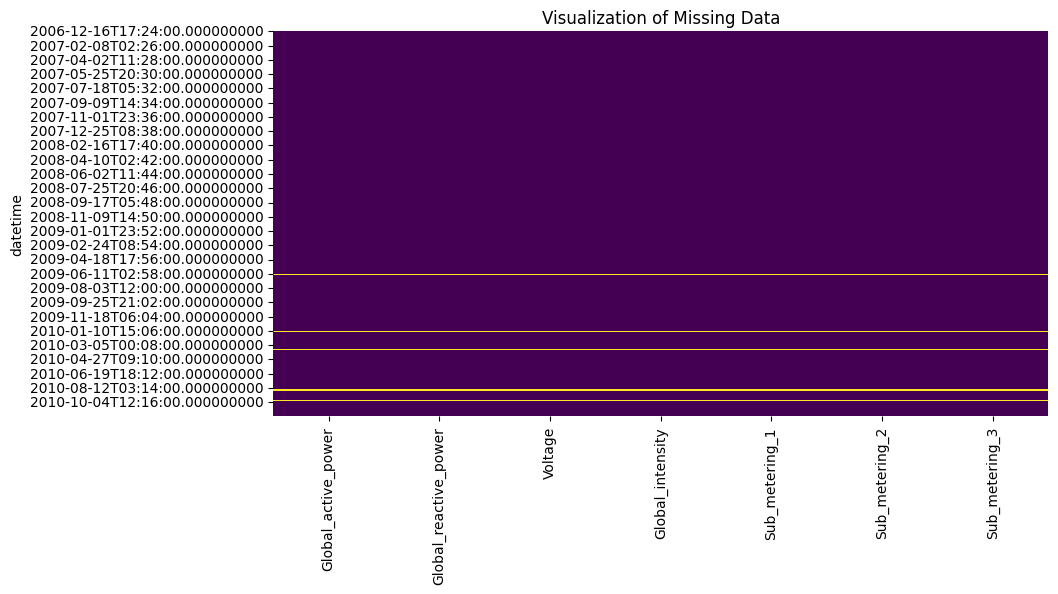

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isna(), cbar=False, cmap='viridis')
plt.title('Visualization of Missing Data')
plt.show()

In [ ]:
# Frequency: per minute?
diffs = df.index.to_series().diff()
diff_counts = diffs.value_counts().head(20)
print(diff_counts)

print("Mode:", diffs.mode().iloc[0])

datetime
0 days 00:01:00    2075258
Name: count, dtype: int64
Mode: 0 days 00:01:00


## 1.4 Resampling to Hourly Frequency

Each measurement in the dataset has 1-minute intervals.

Because the time axis is very frequent (minute-by-minute), there are millions of rows in total (~2 million).

We want to simplify the dataset for hourly analysis:

- <font color='blue'>**We resample the data into 1-hour periods, taking the average value for each hour.**</font>


As a result :
- It significantly reduces the data size (2 million rows → around 34,000 rows).

- Analysis becomes easier: we can see hourly, daily, or weekly energy trends.

- Identifying gaps becomes easier. Because NaN only occurs at certain times.


In [ ]:
df_hour = df.resample('H').mean()
print("Number of rows per hour:", len(df_hour))
print("Number of hours containing at least 1 NaN:", df_hour.isna().any(axis=1).sum())
print("Missing values in hourly columns::\n", df_hour.isna().sum())

Number of rows per hour: 34589
Number of hours containing at least 1 NaN: 421
Missing values in hourly columns::
 Global_active_power      421
Global_reactive_power    421
Voltage                  421
Global_intensity         421
Sub_metering_1           421
Sub_metering_2           421
Sub_metering_3           421
dtype: int64


**Now there is only one line for each hour**


🕐 Resampling Behavior (Minute → Hour)

- If at least one valid record exists within an hour, the hourly mean is calculated.
- If all records in that hour are missing, the entire hour becomes NaN.

📊 Column-wise Missing Values

- Each column is resampled independently.
- If a column has some valid values, its hourly mean is computed.
- Only columns with all missing values for that hour become NaN.

## 1.5 Missing Value Imputation

After resampling to hourly frequency, some hours have missing values due to incomplete or missing minute data.

To handle this:

- We analyze missing patterns to detect where NaNs occur.

- **Short gaps (≤ 3 hours) are filled using time-based interpolation**, ensuring smooth and realistic transitions.

- Long gaps (> 3 hours) remain missing, since filling them could distort the data.

This method keeps the time series continuous while preserving data integrity.

----------------

**Interpolation**: A method to estimate and fill missing values using nearby data points in time.

For example:

| Time  | Value |
| ----- | ----- |
| 10:00 | 5     |
| 11:00 | NaN   |
| 12:00 | 9     |


Here, the value at 11:00 is missing.
Interpolation predicts it (e.g., 7) based on the trend between 10:00 and 12:00.

In [ ]:
def clean_and_impute(
    df_hourly,
    gap_threshold_hours=24,
    interp_limit_hours=3,
    out_data_path='household_hourly_cleaned.parquet',
    out_mask_path='household_hourly_imputed_mask.parquet'
):

    """
    gap_threshold_hours = 24
    → Gaps longer than 24 hours are large gaps → removed
    interp_limit_hours = 3
    → Gaps shorter than or equal to 3 hours → filled using interpolation
    """

    # 1- --- Detect gaps ---
    is_nan = df_hourly.isna().all(axis=1)

    """
    Consecutive Trues -> receive a group number.
    This means that each block of missing values ​​becomes a single group.

    shift(1): takes the previous value
    """
    change_points = (is_nan != is_nan.shift(1)).cumsum()

    # Only NaN groups
    nan_groups = is_nan[is_nan].index.to_series().groupby(change_points)

    gaps = []

    for group_id, group_data in nan_groups:
        if not group_data.empty:
            start = group_data.index[0]
            end = group_data.index[-1]
            # Calculating the difference in hours
            duration_hours = int((end - start).total_seconds() / 3600) + 1
            gaps.append((start, end, duration_hours))

    """
    gaps → sample:
    (Timestamp('2007-04-28 01:00:00'), Timestamp('2007-04-30 13:00:00'), 61)
    """

    print("GAP List:")
    gap_df = pd.DataFrame(gaps, columns=['Start', 'End', 'Duration_hours'])
    display(gap_df)

    # -----------------------------------------------------

    # 2- --- Drop big gaps ---
    # (>= 24 hour)
    big_gap_indices = []
    for s, e, l in gaps:
      if l >= gap_threshold_hours:
        big_gap_indices.extend(pd.date_range(start=s, end=e, freq='H'))


    """
    Remove indexes from the dataset.
    errors='ignore': If there are missing indexes, it skips them (does not generate an error).
    """
    df_cleaned = df_hourly.drop(index=big_gap_indices, errors='ignore')

    # -----------------------------------------------------

    # 3- --- Interpolate short gaps (<=3h) ---
    df_imputed = df_cleaned.interpolate(method='time', limit=interp_limit_hours,limit_direction='both')

    # Creating a mask for the entered data
    # We find the cleaned (NaN) -> filled (non-NaN) places.
    imputed_mask = df_cleaned.isna() & df_imputed.notna()

    # -----------------------------------------------------

    # 4- --- Final cleanup ---
    # Removes medium-sized gaps (>3h – 24h<) that remain fully empty after interpolation.
    df_final = df_imputed.dropna(how='all')

    # 5- --- Save ---
    df_final.to_parquet(out_data_path)
    imputed_mask.to_parquet(out_mask_path)

    print(f"Detected {len(gaps)} total gaps")
    print(f"Removed {len(big_gap_indices)} hourly records from large gaps (>{gap_threshold_hours}h)")
    print(f"Interpolated gaps up to {interp_limit_hours} hours long")
    print(f"Rows removed by dropna (medium-sized gaps (>3h – 24h<)): {len(df_imputed) - len(df_final)}")
    print(f"Final shape: {df_final.shape}")
    print(f"Imputed cells: {imputed_mask.sum().sum()}")
    print(f"Dropped rows: {len(df_hourly) - len(df_final)}")

    return df_final,imputed_mask


In [ ]:
df_final,imputed_mask = clean_and_impute(df_hour)

GAP List:


,Start,End,Duration_hours
0,2007-04-28 01:00:00,2007-04-30 13:00:00,61
1,2007-07-15 17:00:00,2007-07-15 17:00:00,1
2,2009-06-13 01:00:00,2009-06-15 06:00:00,54
3,2009-08-13 05:00:00,2009-08-13 18:00:00,14
4,2010-01-12 15:00:00,2010-01-14 18:00:00,52
5,2010-03-20 04:00:00,2010-03-21 12:00:00,33
6,2010-08-17 22:00:00,2010-08-22 20:00:00,119
7,2010-09-25 04:00:00,2010-09-28 18:00:00,87


Detected 8 total gaps
Removed 406 hourly records from large gaps (>24h)
Interpolated gaps up to 3 hours long
Rows removed by dropna (medium-sized gaps (>3h – 24h<)): 8
Final shape: (34175, 7)
Imputed cells: 49
Dropped rows: 414


In [ ]:
df_final.isnull().sum()

,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0


In [ ]:
df_final.describe().T

,count,mean,std,min,25%,50%,75%,max
Global_active_power,34175.0,1.091721,0.897563,0.124000,0.341950,0.802833,1.579417,6.560533
Global_reactive_power,34175.0,0.123739,0.066854,0.000000,0.078000,0.106933,0.149433,0.774333
Voltage,34175.0,240.839537,3.000819,225.834500,239.181250,240.978167,242.694500,251.902000
Global_intensity,34175.0,4.628230,3.757553,0.503333,1.513333,3.423333,6.608333,28.383333
Sub_metering_1,34175.0,1.121401,3.537720,0.000000,0.000000,0.000000,0.000000,48.366667
Sub_metering_2,34175.0,1.299169,4.192859,0.000000,0.000000,0.333333,0.650000,46.433333
Sub_metering_3,34175.0,6.458765,7.350724,0.000000,0.650000,1.650000,14.216667,21.550000


# 2.Feature Engineering





## 2.1 Time-based Features

**Time-based Features** :

- We have hourly energy consumption data.

- If the model only looks at numbers such as “how many kWh were consumed right now,” it cannot know what time or day it was.

- But electricity consumption varies greatly depending on the time of day, whether it is a weekend or not, and the month.

- **We can add time-based columns to understand this.**

Columns :

- **hour**: Time of day (0–23)
- **dayofweek** : Day of the week (0=Mon, 6=Sun)
- **is_weekend**: Hafta sonu = 1, hafta içi = 0
- **month** : Month number (1–12)
- **hour_sin, hour_cos** : Sine and cosine transformation of time  (To teach that time is cyclical.)


**Source =>  [Cyclic Encoding: Sine and Cosine Transformations for Periodic Features](https://www.kaggle.com/discussions/general/491296)**

----------------
**Imputation-mask Features** :
- Since some missing values were filled by interpolation, I added mask columns to keep track of them.
- Each mask indicates whether the value was originally measured (0) or filled by interpolation (1).
- This helps future analysis or models understand which data points are fully reliable.

**NOT: It was initially added but removed as its effect was not observed in solving this problem.**

In [ ]:
df_final.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [ ]:
# assume df_final and imputed_mask are in memory; if not, load from parquet
try:
    df_feature = df_final.copy()
    mask = imputed_mask.copy()
except NameError:
    df_feature = pd.read_parquet('household_hourly_cleaned.parquet')
    mask = pd.read_parquet('household_hourly_imputed_mask.parquet')


df_feature = df_feature.sort_index()

# -----------------------------------------------------

# --- Time Features ---
df_feature['hour'] = df_feature.index.hour
df_feature['hour_sin'] = np.sin(2 * np.pi * df_feature['hour'] / 24)
df_feature['hour_cos'] = np.cos(2 * np.pi * df_feature['hour'] / 24)
df_feature['dayofweek'] = df_feature.index.dayofweek
df_feature['is_weekend'] = (df_feature['dayofweek'] >= 5).astype(int)
df_feature['month'] = df_feature.index.month

# -----------------------------------------------------
# ---  Imputation-mask Features --- ! Canceled
"""
mask = mask.reindex(df.index).fillna(False)
for col in mask.columns:
    df[f'was_imputed_{col}'] = mask[col].astype(int)
"""
# -----------------------------------------------------

df_features = df_feature.copy()
print("Feature:")
display(df_features.head())
print("\nShape:", df_features.shape)


Feature:


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,hour_sin,hour_cos,dayofweek,is_weekend,month
datetime,,,,,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,17,-0.965926,-2.588190e-01,5,1,12
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,18,-1.000000,-1.836970e-16,5,1,12
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,19,-0.965926,2.588190e-01,5,1,12
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,20,-0.866025,5.000000e-01,5,1,12
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,21,-0.707107,7.071068e-01,5,1,12



Shape: (34175, 13)


# 3.Data Preprocessing

In [ ]:
corr = df_features.corr()['Global_active_power'].sort_values(ascending=False)
print(corr)

Global_active_power      1.000000
Global_intensity         0.999423
Sub_metering_3           0.695559
Sub_metering_1           0.496308
Sub_metering_2           0.440192
hour                     0.331696
Global_reactive_power    0.312178
is_weekend               0.099630
dayofweek                0.077461
month                   -0.038288
hour_cos                -0.130075
hour_sin                -0.221749
Voltage                 -0.379457
Name: Global_active_power, dtype: float64


In [ ]:
# Remove columns with very low correlation.
df_features = df_features.drop(columns=['dayofweek','month'])

## 3.1 Preparing the Data



### 🎯 Target Variable
- **`Global_active_power`** — represents the household’s total active power consumption and serves as the **target variable** for prediction.


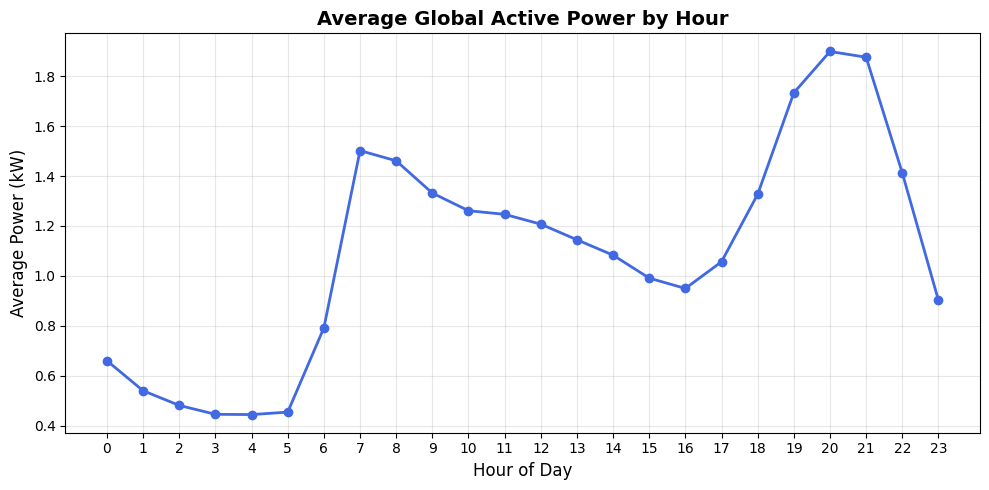

In [ ]:
plt.figure(figsize=(10, 5))
df_features.groupby(df_features.index.hour)['Global_active_power'].mean().plot(
    kind='line',
    color='royalblue',
    marker='o',
    linewidth=2,
)

plt.title('Average Global Active Power by Hour', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Power (kW)', fontsize=12)
plt.grid(alpha=0.3)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


**📊 Interpretation**

The chart shows the average hourly electricity consumption pattern in the household.

- **Lowest usage:** Between **00:00 and 05:00**, when household activity is minimal.  
- **Morning peak:** Around **07:00–08:00**, likely due to cooking and appliance use.  
- **Stable period:** Between **10:00 and 16:00**, with moderate consumption.  
- **Evening peak:** Around **19:00–21:00**, the highest energy demand of the day.  
- **After 22:00**, power usage drops again as daily activities end.

Overall, the data clearly reflects a **daily cycle** of energy consumption, with two main peaks corresponding to typical household routines.


<Axes: title={'center': 'Lag Correlation with Target'}>

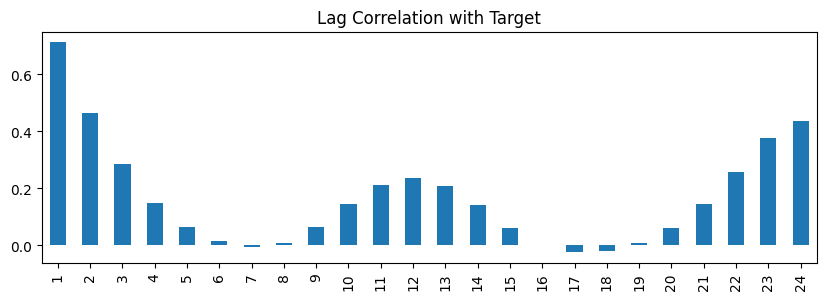

In [ ]:
target_col = 'Global_active_power'

lags = range(1, 25)
lag_corrs = {lag: df_features[target_col].corr(df_features[target_col].shift(lag)) for lag in lags}

pd.Series(lag_corrs).plot(kind='bar', figsize=(10,3), title='Lag Correlation with Target')


**Most recent lags (1–2 steps) show strong correlation with the target, and a smaller peak around lag 24 suggests daily cyclicity.**

In [ ]:
# PARAMETERS
timesteps = 24   # lookback window (hours)
horizon = 1      # (hours ahead)
train_frac = 0.70
val_frac = 0.15

## 3.2 Train-Test Split

🔹 Why do we split the data (train/val/test)?

With time series data, we have to learn without seeing the future.
That's why **we split the data according to time**:


```
Past --------------> Future


|---- train ----|---- val ----|---- test ----|

```

Train: the model learns from past data

Validation: we test the model's settings

Test: we measure how well the model predicts in a completely new time period

In [ ]:
# choose feature columns
X_cols = [c for c in df_features.columns if c != target_col]


df_size = len(df_features)
i_train = int(df_size * train_frac)
i_val = int(df_size * (train_frac + val_frac))

df_train = df_features.iloc[:i_train] # %70
df_val = df_features.iloc[i_train:i_val] # %15
df_test = df_features.iloc[i_val:] # %15

print("Lengths : train/val/test =", len(df_train), len(df_val), len(df_test))


Lengths : train/val/test = 23922 5126 5127


**Chronologically split, without shuffle**

## 3.3 Data Normalization / Scaling

### 🔹 Why fit only on the training set

- **We fit the scaler only on the training set to avoid data leakage**
- Then, we apply the same scaling parameters (mean and std ...) to validation and test sets.
- This keeps all data on the same scale and ensures a fair evaluation.


**🔹 Scaler Choice**

I used **StandardScaler** because it normalizes features (mean = 0, std = 1),
is less sensitive to outliers, and works stably with RNN models.

---

###🔹 What is Data Leakage?

- **Data leakage happens when information from the validation or test set accidentally influences the model during training.**
- This makes the model look unrealistically good. But it won’t perform well on real unseen data.

**📘 Always preprocess (fit, scale,..) using only the training data.**

In [ ]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Only train on the training data (to prevent information leakage)
scaler_X.fit(df_train[X_cols].values)
scaler_y.fit(df_train[[target_col]].values)  # 2D for y scaler


def scale_df(df_in):
    Xs = scaler_X.transform(df_in[X_cols].values)
    ys = scaler_y.transform(df_in[[target_col]].values).ravel() # 1D
    dfX = pd.DataFrame(Xs, index=df_in.index, columns=X_cols)
    dfY = pd.Series(ys, index=df_in.index, name=target_col)
    return dfX, dfY

X_train_df, y_train_s = scale_df(df_train)
X_val_df, y_val_s   = scale_df(df_val)
X_test_df, y_test_s  = scale_df(df_test)

In [ ]:
print("Shapes -> X_train_df, X_val_df, X_test_df:", X_train_df.shape, X_val_df.shape, X_test_df.shape)
print("Shapes -> y_train_s, y_val_s, y_test_s:", y_train_s.shape, y_val_s.shape, y_test_s.shape)
print("\n--- X_train_df (scaled) ---")
display(X_train_df.head(3))
print("\n--- y_train_s (scaled) ---")
display(y_train_s.head(5))

Shapes -> X_train_df, X_val_df, X_test_df: (23922, 10) (5126, 10) (5127, 10)
Shapes -> y_train_s, y_val_s, y_test_s: (23922,) (5126,) (5127,)

--- X_train_df (scaled) ---


,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,hour_sin,hour_cos,is_weekend
datetime,,,,,,,,,,
2006-12-16 17:00:00,1.619261,-1.911240,3.461318,-0.318242,-0.191655,1.495422,0.793790,-1.365321,-0.366482,1.588271
2006-12-16 18:00:00,-0.612151,-1.932087,2.819446,-0.318242,1.213910,1.496191,0.938221,-1.413506,-0.000433,1.588271
2006-12-16 19:00:00,-0.534258,-2.372993,2.537878,-0.318242,0.014007,1.470812,1.082652,-1.365321,0.365616,1.588271



--- y_train_s (scaled) ---


,Global_active_power
datetime,
2006-12-16 17:00:00,3.375292
2006-12-16 18:00:00,2.739628
2006-12-16 19:00:00,2.490000
2006-12-16 20:00:00,2.348308
2006-12-16 21:00:00,2.120059


<font color='blue'>**Scalers were fitted on the training data, then applied to all sets.**</font>

- Train data → mean = 0, std = 1

- Val/test → close to mean ≈ 0, std ≈ 1

## 3.4 Lookback Feature Creation

**Creating sequences (time windows) with scaled data**

Scaled Data : **2D (time_samples , features) =>
make_sequences => 3D (time_samples, timesteps, features)**



<font color='red'>**RNN -> input format (3D)**: </font>(num_samples, timesteps, num_features)



In [ ]:
np.array(X_train_df.values[0:2]).shape

(2, 10)

In [ ]:
# make sequences (sliding windows, no shuffling here)

def make_sequences(X_df, y_series, timesteps=24, horizon=1):
    X_arr = X_df.values # 2D
    y_arr = y_series.values

    # If the data length is less than (timesteps + horizon)
    n_samples = len(X_arr) - timesteps - (horizon - 1) + 1

    if n_samples <= 0:
        return np.empty((0, timesteps, X_arr.shape[1])), np.empty((0,))

    # ---------------------

    Xs, ys = [], []

    for i in range(timesteps, len(X_arr) - horizon + 1):

        Xs.append(X_arr[i-timesteps:i]) # 3D
        ys.append(y_arr[i + horizon - 1])
        """
        Example: timesteps = 24, horizon = 1,
        i = 24 ;
        X = data from hours [0 ... 23]
        y = value at hour [24]  → the next hour to predict
        """

    return np.array(Xs), np.array(ys)


In [ ]:
X_train, y_train = make_sequences(X_train_df, y_train_s, timesteps=timesteps, horizon=horizon)
X_val,   y_val   = make_sequences(X_val_df,   y_val_s,   timesteps=timesteps, horizon=horizon)
X_test,  y_test  = make_sequences(X_test_df,  y_test_s,  timesteps=timesteps, horizon=horizon)


print("Sclaled Data Shapes -> X_train_df, X_val_df, X_test_df:", X_train_df.shape, X_val_df.shape, X_test_df.shape)
print("Sclaled Data Shapes -> y_train_s, y_val_s, y_test_s:", y_train_s.shape, y_val_s.shape, y_test_s.shape)


print("\nLookback Data Shapes:")
print("X_train, y_train:", X_train.shape, y_train.shape)
print("X_val,   y_val:  ", X_val.shape, y_val.shape)
print("X_test,  y_test: ", X_test.shape, y_test.shape)


Sclaled Data Shapes -> X_train_df, X_val_df, X_test_df: (23922, 10) (5126, 10) (5127, 10)
Sclaled Data Shapes -> y_train_s, y_val_s, y_test_s: (23922,) (5126,) (5127,)

Lookback Data Shapes:
X_train, y_train: (23898, 24, 10) (23898,)
X_val,   y_val:   (5102, 24, 10) (5102,)
X_test,  y_test:  (5103, 24, 10) (5103,)


Our **line count decreased** because:
- <font color='green'>
The model uses a 24-hour lookback window, the first 23 rows don’t have enough past data to form a full sequence.</font>
- <font color='blue'>
Therefore, sequence generation starts from the 24th hour onward.
</font>


In [ ]:
# sample: first sequence 0, first 2 timesteps
print(X_train[0][:2])

[[ 1.61926078e+00 -1.91123957e+00  3.46131785e+00 -3.18241739e-01
  -1.91654745e-01  1.49542228e+00  7.93790459e-01 -1.36532079e+00
  -3.66481870e-01  1.58827058e+00]
 [-6.12150664e-01 -1.93208709e+00  2.81944564e+00 -3.18241739e-01
   1.21390987e+00  1.49619134e+00  9.38221380e-01 -1.41350584e+00
  -4.32728048e-04  1.58827058e+00]]


# 4.Modelling  (RNN)

## 🔹 What is our goal with RNN?

Our model wants to predict the future.
So we want the model to work like this:

**“Look at the values of past hours → predict the next hour.”**

---

**Why are we predicting 1 hour?**

The model's prediction horizon comes into play here.

**horizon = 1 , timesteps (lookback) = 24  means:**

**Use 24 hours of past data, predict 1 hour ahead.**

So 24 inputs → 1 output.

🧩 Visual example:

```
Hours: [1 ... 24] → estimate: hour 25
Hours: [2 ... 25] → estimate: hour 26
Hours: [3 ... 26] → estimate: hour 27

```

- The model creates many examples in this way, using a “sliding window.”
- <font color='blue'>**Each time, it learns to predict the next hour using a window of the past 24 hours.**</font>
<br>

<font color='red'>**Sliding window : </font> A new sample is created by sliding 1 hour each time.**

<br>

![Sliding Window Technique](images/SlidingWindowTechnique.png)

*Figure 1. Illustration of the sliding window technique to create input features and labels from time-series datasets.*

*Source: [ResearchGate - "Illustration of the sliding window technique"](https://www.researchgate.net/figure/llustration-of-the-sliding-window-technique-to-create-input-features-and-labels-from_fig2_348379817),
licensed under CC BY-NC-SA 4.0. Used for academic purposes only.*

---
**Why don't we forecast all 20 hours at once?**

We could do that if we wanted to, but:

- That would be multi-step forecasting (e.g., horizon=24).

- It's a more difficult problem because errors accumulate.

- Starting with one-step-ahead forecasting is more stable and more instructive.

---
**Note**: `tanh and sigmoid` functions were also studied. However,
**`ReLU` activation performed better** in this model.

In [ ]:
model = Sequential([
    SimpleRNN(64, activation='relu',
              return_sequences=True,
              input_shape=(X_train.shape[1], X_train.shape[2])), # (24,12)
    Dropout(0.3),
    SimpleRNN(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 24, 64)         │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,937 (31.00 KB)

 Trainable params: 7,937 (31.00 KB)

 Non-trainable params: 0 (0.00 B)

## 4.1 Model Building

- **MAE (Mean Absolute Error)** : takes the absolute value of the difference of each prediction and calculates its average. (lower is better.)

- **MSE (Mean Squared Error)** measures the average of the squares of prediction errors.

  
Difference (according to MAE): **MSE is more sensitive to outliers**.


**Gradient Clipping (clipnorm)**:

- `clipnorm` limits the overall norm of gradients during training to **prevent exploding gradients**, which often occur in RNN-based models.  
- By setting `clipnorm=2.0`, gradients with a norm greater than 2 are scaled down, ensuring **stable and smoother learning**.


---

**Callbacks**:
- **EarlyStopping** prevents overfitting by stopping training when validation loss stops improving.
- **ModelCheckpoint** saves the model with the lowest validation loss.

In [ ]:
model.compile(loss='mean_squared_error', # Continuous value estimation (regression)
              metrics=['mae'],
              optimizer=Adam(learning_rate=0.001,clipnorm=2.0))

In [ ]:
callbacks = [EarlyStopping(
                 monitor='val_loss',
                 patience=8, verbose=1, mode='min'),

             ModelCheckpoint(
                 filepath='home_electricity_consumption_model.keras',
                 monitor='val_loss', mode='min',
                 save_best_only=True, save_weights_only=False, verbose=1),

             ReduceLROnPlateau(monitor='val_loss',
                              factor=0.5, patience=5,
                              min_lr=1e-6, verbose=1)
              ]

## 4.2 Model Training

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
1493/1494 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6699 - mae: 0.5975
Epoch 1: val_loss improved from inf to 0.40289, saving model to home_electricity_consumption_model.keras
1494/1494 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - loss: 0.6697 - mae: 0.5974 - val_loss: 0.4029 - val_mae: 0.4519 - learning_rate: 0.0010
Epoch 2/50
1494/1494 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4337 - mae: 0.4730
Epoch 2: val_loss improved from 0.40289 to 0.35003, saving model to home_electricity_consumption_model.keras
1494/1494 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 0.4337 - mae: 0.4730 - val_loss: 0.3500 - val_mae: 0.4144 - learning_rate: 0.0010
Epoch 3/50
1490/1494 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4043 - mae: 0.4532
Epoch 3: val_loss improved from 0.35003 to 0.34886, saving model to home_electricity_consumption_model.keras
1494/1494 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 0.4043 - mae: 0.4532 - val_loss: 0.3489 - val_mae: 0.4180 - learning_rate: 0.0010
Epoch 4/50
1493/1494

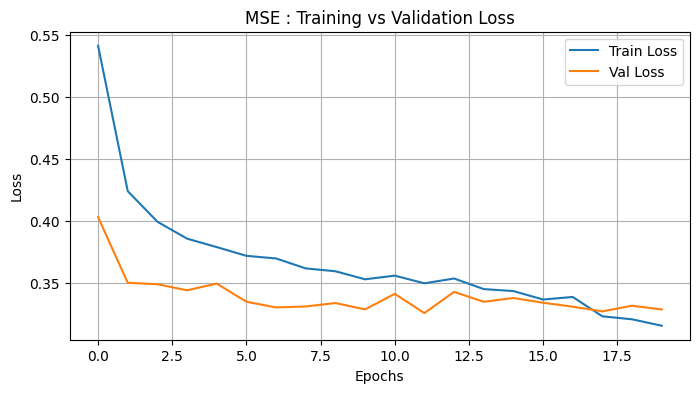

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('MSE : Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

**The validation loss has stopped decreasing, and therefore early stopping has occurred.**

## 4.3 Model Evaluation (Metrics & Plots)

In [ ]:
best_model = load_model("home_electricity_consumption_model.keras")

In [ ]:
val_loss, val_mae = best_model.evaluate(X_val, y_val, batch_size=1)
test_loss, test_mae = best_model.evaluate(X_test, y_test, batch_size=1)

print(f"Validation - MSE : {val_loss:.3f}  MAE: {val_mae:.3f} ")
print(f"Test - MSE : {test_loss:.3f}  MAE: {test_mae:.3f}")

5102/5102 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - loss: 0.3116 - mae: 0.3896
5103/5103 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 0.2487 - mae: 0.3512
Validation - MSE : 0.326  MAE: 0.396 
Test - MSE : 0.257  MAE: 0.355


## 4.4  ♦️◆♦️ **P R E D I C T I O N** ♦️◆♦️

In [ ]:
# Predict (scaled)
train_pred_scaled = best_model.predict(X_train)
val_pred_scaled = best_model.predict(X_val)
test_pred_scaled = best_model.predict(X_test)


# Inverse transform (original scale)
y_train_inv = scaler_y.inverse_transform(y_train.reshape(-1,1)).ravel() # 1D
y_train_pred_inv = scaler_y.inverse_transform(train_pred_scaled.reshape(-1,1)).ravel()

y_val_inv = scaler_y.inverse_transform(y_val.reshape(-1,1)).ravel() # 1D
y_val_pred_inv = scaler_y.inverse_transform(val_pred_scaled.reshape(-1,1)).ravel()

y_test_inv = scaler_y.inverse_transform(y_test.reshape(-1,1)).ravel() # 1D
y_test_pred_inv = scaler_y.inverse_transform(test_pred_scaled.reshape(-1,1)).ravel()


# Real metrics
print("------------ Real metrics ------------\n")

train_mse = mean_squared_error(y_train_inv, y_train_pred_inv)
train_rmse = np.sqrt(train_mse)
train_mae = np.mean(np.abs(y_train_inv - y_train_pred_inv))
print(f"Train - MSE : {train_mse:.3f} RMSE : {train_rmse:.3f} MAE : {train_mae:.3f} \n")

val_mse = mean_squared_error(y_val_inv, y_val_pred_inv)
val_rmse = np.sqrt(val_mse)
val_mae = np.mean(np.abs(y_val_inv - y_val_pred_inv))
print(f"Val - MSE : {val_mse:.3f} RMSE : {val_rmse:.3f} MAE : {val_mae:.3f} \n")

test_mse = mean_squared_error(y_test_inv, y_test_pred_inv)
test_rmse = np.sqrt(test_mse)
test_mae = np.mean(np.abs(y_test_inv - y_test_pred_inv))
print(f"Test - MSE : {test_mse:.3f} RMSE : {test_rmse:.3f} MAE : {test_mae:.3f} ")


747/747 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
------------ Real metrics ------------

Train - MSE : 0.264 RMSE : 0.514 MAE : 0.351 

Val - MSE : 0.281 RMSE : 0.530 MAE : 0.368 

Test - MSE : 0.222 RMSE : 0.471 MAE : 0.330 


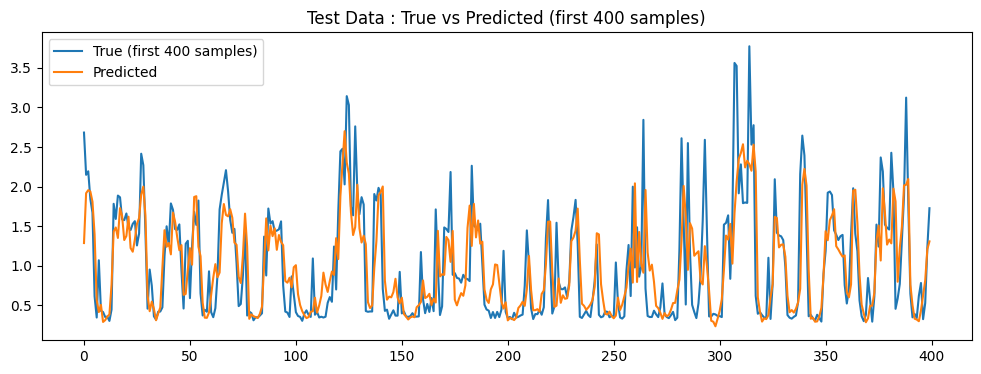

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(y_test_inv[:400], label='True (first 400 samples)')
plt.plot(y_test_pred_inv[:400], label='Predicted')
plt.legend();
plt.title('Test Data : True vs Predicted (first 400 samples)');
plt.show()

In [ ]:
df_features[target_col].describe().T

,Global_active_power
count,34175.000000
mean,1.091721
std,0.897563
min,0.124000
25%,0.341950
50%,0.802833
75%,1.579417
max,6.560533


In [ ]:
test_prediction_df =  df_features[[target_col]].iloc[i_val + timesteps:].copy()
test_prediction_df['Predicted'] = y_test_pred_inv
test_prediction_df.head(5)

,Global_active_power,Predicted
datetime,,
2010-04-19 17:00:00,2.682733,1.285901
2010-04-19 18:00:00,2.148533,1.916346
2010-04-19 19:00:00,2.193467,1.954813
2010-04-19 20:00:00,1.841633,1.937592
2010-04-19 21:00:00,1.670500,1.808930


In [ ]:
val_prediction_df =  df_features[[target_col]].iloc[i_train+timesteps:i_val].copy()
val_prediction_df['Predicted'] = y_val_pred_inv
val_prediction_df.head(5)

,Global_active_power,Predicted
datetime,,
2009-09-14 14:00:00,0.695600,1.015493
2009-09-14 15:00:00,0.618367,0.874348
2009-09-14 16:00:00,0.557300,0.855120
2009-09-14 17:00:00,0.338800,0.854593
2009-09-14 18:00:00,1.044733,0.749837


In [ ]:
train_prediction_df =  df_features[[target_col]].iloc[timesteps:i_train].copy()
train_prediction_df['Predicted'] = y_train_pred_inv
train_prediction_df.head(5)

,Global_active_power,Predicted
datetime,,
2006-12-17 17:00:00,3.406767,3.243548
2006-12-17 18:00:00,3.697100,3.629823
2006-12-17 19:00:00,2.908400,3.523072
2006-12-17 20:00:00,3.361500,2.941233
2006-12-17 21:00:00,3.040767,3.090204


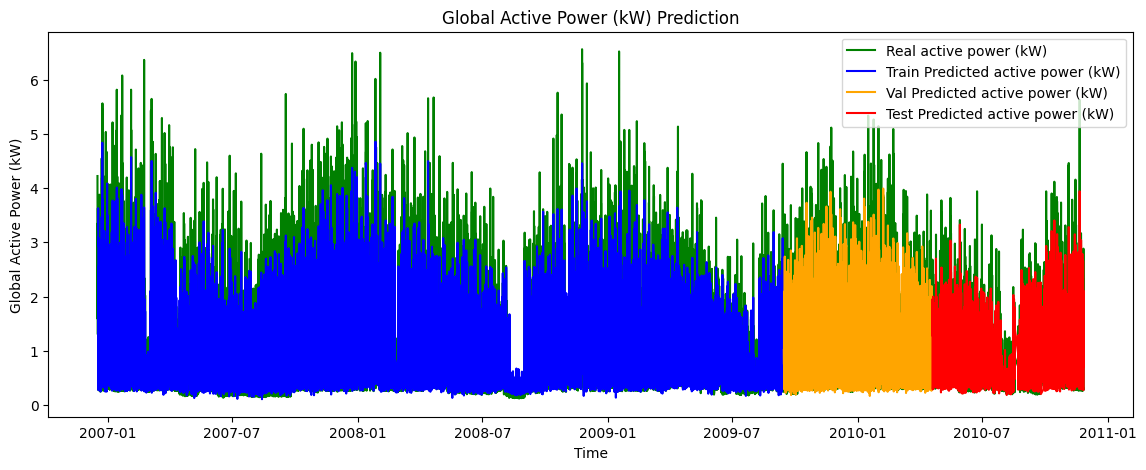

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df_features[target_col],color='green', label='Real active power (kW)')
plt.plot(train_prediction_df['Predicted'], color='blue', label='Train Predicted active power (kW)')
plt.plot(val_prediction_df['Predicted'], color='orange', label='Val Predicted active power (kW)')
plt.plot(test_prediction_df['Predicted'], color='red', label='Test Predicted active power (kW)')
plt.title('Global Active Power (kW) Prediction')
plt.xlabel('Time')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.show()